## Ugropy power users

In this final section of the tutorial, we will explore some advanced features of
`ugropy` that were not covered in the previous sections. These features are
intended for users who want to customize the behavior of the already
implemented models in `ugropy` or who want to implement their own models.

### Non-optimal solutions

As explained in previous sections, `ugropy` allows you to search for multiple
solutions for the models, but all these solutions are optimal (they use the same
number of groups to represent the molecule). However, it is possible to search for
non-optimal solutions along with the optimal ones. This is useful when you want 
to find all possible combinations of fragments that cover the molecule.
Please note that this feature is intended for research purposes and is not 
recommended for actually modeling molecules.

We can enable this for all `ugropy` models using the `search_nonoptimal`
parameter:

In [1]:
from ugropy import unifac

solutions = unifac.get_groups(
    "9,10-dihydroanthracene",
    search_multiple_solutions=True, # If this is False, search_nonoptimal is ignored
    search_nonoptimal=True,
)

# Three solutions were found:
solutions

We can visualize all the obtained solutions:

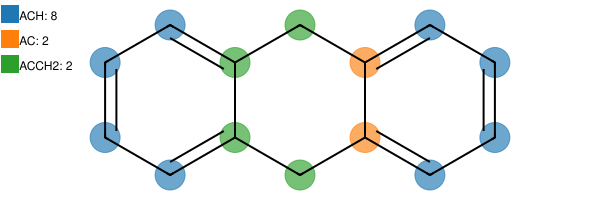

In [2]:
solutions[0].draw(width=600)

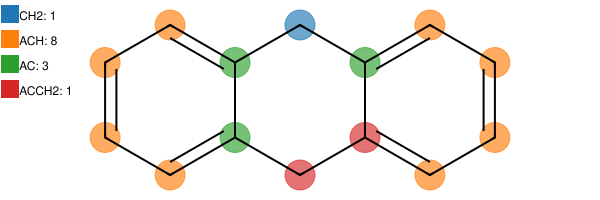

In [3]:
solutions[1].draw(width=600)

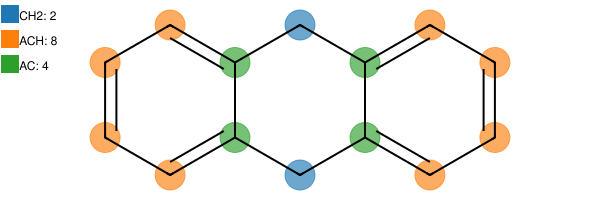

In [4]:
solutions[2].draw(width=600)

If you are an experienced user of UNIFAC-like models, you may notice that the
only "correct" solution is the first one. When non-optimal solutions are
enabled, the algorithm will always find the optimal solutions first, and then
it will search for non-optimal solutions in a "non-optimal" order.

### Changing the default ILP solver

By default, `ugropy` uses the standard CBC solver from the `PuLP` library.
However, `PuLP` supports a wide variety of solvers. Changing the ILP solver can
significantly impact the library's execution time. A great alternative is the
`XPRESS_PY` solver.

First, you must install `XPRESS`:

```shell
pip install xpress
```

Then, you can change the default solver by passing it as an argument:

/home/salvador/.virtualenvs/ugropy/lib/python3.12/site-packages/pulp/apis/xpress_api.py:751: LicenseWarning: Using the Community license in this session. If you have a full Xpress license, pass the full path to your license file to xpress.init(). If you want to use the FICO Community license and no longer want to see this message, use the following code before using the xpress module:
  xpress.init('/home/salvador/.virtualenvs/ugropy/lib/python3.12/site-packages/xpresslibs/bin/community-xpauth.xpr')
  model = xpress.problem()
/home/salvador/.virtualenvs/ugropy/lib/python3.12/site-packages/pulp/apis/xpress_api.py:774: DeprecationWarning: Deprecated in Xpress 9.8: use problem.addCols instead.
  model.addcols(obj, [0] * (len(obj) + 1), [], [], lb, ub, names, ctype)


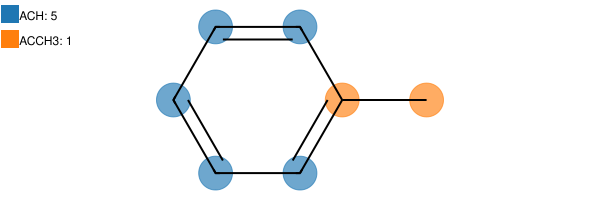

In [5]:
from ugropy import unifac


unifac.get_groups("toluene", solver_arguments={"solver": "XPRESS_PY"}).draw(width=600)

### Understanding model instances and their configuration

`ugropy` is designed using the singleton pattern; therefore, all the models we
have been using throughout this tutorial are instances of the `FragmentationModel` 
class. This class possesses several attributes that can be used to inspect 
the models' information and definitions.

Each model in `ugropy` is composed of two distinct classes:
`FragmentationModel` and `FragmentationResult`.

The `FragmentationModel` class contains all the fundamental information 
about a model, such as its fragment definitions. It serves as the base class 
required to define a minimal model and implements the `get_groups` method. 
The specific models in `ugropy` are not direct instances of this base class, 
but rather instances of subclasses that inherit from it. For example, the 
UNIFAC model is an instance of the `GibbsModel` class (a subclass of 
`FragmentationModel`). The advantage of these subclasses is that they provide 
additional methods (such as multiple-solution filtering). Furthermore, a 
`GibbsModel` requires more detailed fragment information to be instantiated, 
such as the $R$ and $Q$ parameters.

Finally, each `FragmentationModel` returns an instance of its specific 
`FragmentationResult` subclass when the `get_groups` method is called. In the 
case of a `GibbsModel`, the `get_groups` method returns a 
`GibbsFragmentationResult` instance (which inherits from `FragmentationResult`). 
This architectural design allows different models to perform specific 
post-processing tasks after fragment detection. For instance, the 
`GibbsFragmentationResult` class automatically calculates the $R$ and $Q$ values 
of the solution, while the `JobackFragmentationResult` class computes the 
Joback group-contribution properties.

Understanding this architecture is important because it guarantees that while 
all models share the core attributes and methods required by the 
`FragmentationModel` base class, they also offer specialized features 
depending on their specific subclass.

Let's examine the documentation of a base `FragmentationModel` class (you can 
always check the API documentation for the complete list of methods and attributes).

In [6]:
from ugropy import FragmentationModel

help(FragmentationModel)

Help on class FragmentationModel in module ugropy.core.frag_classes.base.fragmentation_model:

class FragmentationModel(builtins.object)
 |  FragmentationModel(subgroups: pandas.DataFrame, allow_overlapping: bool = False, allow_free_atoms: bool = False, fragmentation_result: ugropy.core.frag_classes.base.fragmentation_result.FragmentationResult = <class 'ugropy.core.frag_classes.base.fragmentation_result.FragmentationResult'>) -> None
 |
 |  FragmentationModel class.
 |
 |  All ugropy supported models are an instance of this class. This class must
 |  be inherited to create a new type of FragmentationModel.
 |
 |  Parameters
 |  ----------
 |  subgroups : pd.DataFrame
 |      Model's subgroups. Index: 'group' (subgroups names). Mandatory columns:
 |      'smarts' (SMARTS representations of the group to detect its presense in
 |      the molecule).
 |  allow_overlapping : bool, optional
 |      Whether allow overlapping or not, by default False
 |  allow_free_atoms : bool, optional
 |  

You can instantiate a base `FragmentationModel` class with the minimum
required information.

This class expects a pandas DataFrame (`subgroups` parameter) that contains a 
specific index and a mandatory column. The index, named `group`, contains the 
names of the fragments, and the column, named `smarts`, contains the SMARTS 
patterns of the fragments. 

The class also accepts a boolean parameter called `allow_overlapping`, which 
indicates whether the model allows the detected fragments within the molecule 
to overlap. Similarly, the `allow_free_atoms` argument indicates whether the 
model allows free atoms (atoms not occupied by any group). Finally, it requires 
a `FragmentationResult` class; by default, the base `FragmentationResult` 
class is used.

In the "Getting Started - About the Algorithm" section of the tutorial, we
defined some models by identifying the fragments directly with the RDKit library. 
Now, let's achieve the same result using the `FragmentationModel` class.

The fragments that we previously defined were:

```python
# Definition of the fragments of our model

# Aliphatic CH2
ch2 = Chem.MolFromSmarts("[CX4H2]")

# Aromatic CH
ach = Chem.MolFromSmarts("[cH]")

# Aromatic C without H
ac = Chem.MolFromSmarts("[cH0]")

# Aromatic C bonded with aliphatic CH2
acch2 = Chem.MolFromSmarts("[cH0][CX4H2]")

# List of fragments of our model
fragments = [ch2, ach, ac, acch2]
fragments_names = ["CH2", "ACH", "AC", "ACCH2"]
```

Let's build a DataFrame with this information (later, you can store it as a
.csv file and load it with pandas to reinstantiate the model):

In [7]:
import pandas as pd

from ugropy import FragmentationModel, FragmentationResult


subgroups = pd.DataFrame(
    {
        "group": ["CH2", "ACH", "AC", "ACCH2"],
        "smarts": ["[CX4H2]", "[cH]", "[cH0]", "[cH0][CX4H2]"],
    },
)

subgroups.set_index("group", inplace=True)

subgroups

,smarts
group,
CH2,[CX4H2]
ACH,[cH]
AC,[cH0]
ACCH2,[cH0][CX4H2]


Now, let's instantiate our model:

In [8]:
our_model = FragmentationModel(
    subgroups=subgroups,
    allow_overlapping=False,
    allow_free_atoms=False,
    fragmentation_result=FragmentationResult
)

We can use this model to fragment a molecule in the same way we used the other
`ugropy` models. The result will be a FragmentationResult instance (you can
check the API documentation for more details on this class). Let's test it with
the same molecule we used in the "About the Algorithm" section of the tutorial.

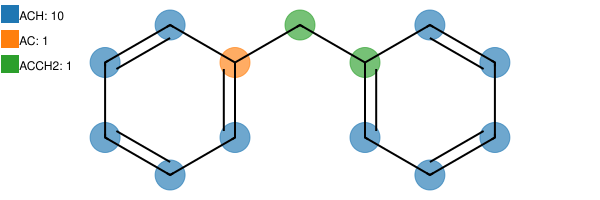

In [9]:
result = our_model.get_groups("c1ccccc1Cc2ccccc2", "smiles")

result.draw(width=600)

This returns the result as a dictionary of group occurrences, using the names 
we defined in our DataFrame as keys:

In [10]:
result.subgroups

{'ACH': 10, 'AC': 1, 'ACCH2': 1}

The specific molecule atoms covered by each fragment can be accessed via the 
`subgroups_atoms` attribute of the `FragmentationResult` instance. This 
attribute is a dictionary where the keys are the fragment names, and the values 
are lists of lists containing the atom indices covered by each occurrence. 
Consequently, the number of nested lists matches the total occurrences of 
that fragment in the molecule.

In [11]:
result.subgroups_atoms

{'ACH': [(0,), (1,), (2,), (3,), (4,), (8,), (9,), (10,), (11,), (12,)],
 'AC': [(5,)],
 'ACCH2': [(7, 6)]}

In [12]:
type(result)

ugropy.core.frag_classes.base.fragmentation_result.FragmentationResult

Since we did not allow overlapping in the previous example, the algorithm found
the optimal solution, ensuring that each atom of the molecule was covered by
only one fragment (while using the minimum number of groups).

Let's see what happens if we allow overlapping:

In [13]:
our_model_olap = FragmentationModel(
    subgroups=subgroups,
    allow_overlapping=True,
    allow_free_atoms=False,
    fragmentation_result=FragmentationResult
)

result_overlapping = our_model_olap.get_groups("c1ccccc1Cc2ccccc2", "smiles")

print(result_overlapping.subgroups)
print(result_overlapping.subgroups_atoms)

{'CH2': 1, 'ACH': 10, 'AC': 2, 'ACCH2': 2}
{'CH2': [(6,)], 'ACH': [(0,), (1,), (2,), (3,), (4,), (8,), (9,), (10,), (11,), (12,)], 'AC': [(5,), (7,)], 'ACCH2': [(5, 6), (7, 6)]}


As you can see, because overlapping was enabled, the algorithm directly
returned all detected fragments in the molecule without searching for an
optimal partition. Consequently, some atoms are now covered by multiple
fragments.

Let's inspect the internal attributes of our `our_model` instance. First, we
can access the same parameters we specified during instantiation. Since these
are attributes of the base class, they are available across all models in
`ugropy`.

In [14]:
print("Fragments of the model:")
print(our_model.subgroups)
print("Allow overlapping:", our_model.allow_overlapping)
print("Allow free atoms:", our_model.allow_free_atoms)
print("Fragmentation result class:", our_model.fragmentation_result)

Fragments of the model:
             smarts
group              
CH2         [CX4H2]
ACH            [cH]
AC            [cH0]
ACCH2  [cH0][CX4H2]
Allow overlapping: False
Allow free atoms: False
Fragmentation result class: <class 'ugropy.core.frag_classes.base.fragmentation_result.FragmentationResult'>


We have an additional, and important, attribute called `detection_mols`:

In [15]:
our_model.detection_mols

{'CH2': <rdkit.Chem.rdchem.Mol at 0x7f841b526e30>,
 'ACH': <rdkit.Chem.rdchem.Mol at 0x7f841b526dc0>,
 'AC': <rdkit.Chem.rdchem.Mol at 0x7f841b526ce0>,
 'ACCH2': <rdkit.Chem.rdchem.Mol at 0x7f841b5273e0>}

When you instantiate a model, during initialization, all the fragments defined
in the DataFrame are used to create a dictionary. This dictionary contains the
fragment names as keys, and the corresponding RDKit Mol objects as values,
which are created internally as:

```python
from rdkit import Chem

mol = Chem.MolFromSmarts(smarts)
```

For this reason, all the SMARTS patterns we define must be compatible with the
`RDKit` library. This attribute is used internally by the `get_groups` method
to search for fragments within the molecule. Pre-building these objects avoids
recreating the `RDKit` `Mol` instances every time `get_groups` is called,
significantly optimizing execution time.

As mentioned before, these are the attributes common to any
`FragmentationModel` subclass, but specific subclasses can implement additional
attributes. For example, an instance of the `GibbsModel` class possesses all
the core attributes we just explored, plus several others:

In [16]:
from ugropy import unifac

# Commented out to avoid printing a large DataFrame
# print("Fragments of the model:", unifac.subgroups)

print("Allow overlapping:", unifac.allow_overlapping)
print("Allow free atoms:", unifac.allow_free_atoms)
print("Fragmentation result class:", unifac.fragmentation_result)
print("Detection mol objects:", unifac.detection_mols)

Allow overlapping: False
Allow free atoms: False
Fragmentation result class: <class 'ugropy.core.frag_classes.gibbs_model.gibbs_result.GibbsFragmentationResult'>
Detection mol objects: {'CH3': <rdkit.Chem.rdchem.Mol object at 0x7f841f10fe60>, 'CH2': <rdkit.Chem.rdchem.Mol object at 0x7f841f10fd10>, 'CH': <rdkit.Chem.rdchem.Mol object at 0x7f841f10fdf0>, 'C': <rdkit.Chem.rdchem.Mol object at 0x7f841f10ff40>, 'CH2=CH': <rdkit.Chem.rdchem.Mol object at 0x7f841f114040>, 'CH=CH': <rdkit.Chem.rdchem.Mol object at 0x7f841f1140b0>, 'CH2=C': <rdkit.Chem.rdchem.Mol object at 0x7f841f114120>, 'CH=C': <rdkit.Chem.rdchem.Mol object at 0x7f841f114190>, 'ACH': <rdkit.Chem.rdchem.Mol object at 0x7f841f114200>, 'AC': <rdkit.Chem.rdchem.Mol object at 0x7f841f114270>, 'ACCH3': <rdkit.Chem.rdchem.Mol object at 0x7f841f1142e0>, 'ACCH2': <rdkit.Chem.rdchem.Mol object at 0x7f841f114350>, 'ACCH': <rdkit.Chem.rdchem.Mol object at 0x7f841f1143c0>, 'OH': <rdkit.Chem.rdchem.Mol object at 0x7f841f114430>, 'CH3OH':

Another example is the `JobackModel` class, which shares the same attributes 
as the base class but also includes an additional attribute called 
`properties_contributions`. This attribute contains the contribution of each 
fragment to the various Joback properties.

In [17]:
from ugropy import joback

# Commented out to avoid printing a large DataFrame
# print("Fragments of the model:", joback.subgroups)

print("Allow overlapping:", joback.allow_overlapping)
print("Allow free atoms:", joback.allow_free_atoms)
print("Fragmentation result class:", joback.fragmentation_result)
print("Detection mol objects:", joback.detection_mols)

# Commented out to avoid printing a large DataFrame
# print("Properties contributions:", joback.properties_contributions)

Allow overlapping: False
Allow free atoms: False
Fragmentation result class: <class 'ugropy.core.frag_classes.joback.joback_result.JobackFragmentationResult'>
Detection mol objects: {'-CH3': <rdkit.Chem.rdchem.Mol object at 0x7f841fdf6730>, '-CH2-': <rdkit.Chem.rdchem.Mol object at 0x7f841fdf66c0>, '>CH-': <rdkit.Chem.rdchem.Mol object at 0x7f841fdf67a0>, '>C<': <rdkit.Chem.rdchem.Mol object at 0x7f841fdf6880>, '=CH2': <rdkit.Chem.rdchem.Mol object at 0x7f841fdf68f0>, '=CH-': <rdkit.Chem.rdchem.Mol object at 0x7f841fdf6960>, '=C<': <rdkit.Chem.rdchem.Mol object at 0x7f841fdf69d0>, '=C=': <rdkit.Chem.rdchem.Mol object at 0x7f841fdf6a40>, 'CH': <rdkit.Chem.rdchem.Mol object at 0x7f841fdf6ab0>, 'C': <rdkit.Chem.rdchem.Mol object at 0x7f841fdf6b20>, 'ring-CH2-': <rdkit.Chem.rdchem.Mol object at 0x7f841fdf6b90>, 'ring>CH-': <rdkit.Chem.rdchem.Mol object at 0x7f841fdf6c00>, 'ring>C<': <rdkit.Chem.rdchem.Mol object at 0x7f841fdf6c70>, 'ring=CH-': <rdkit.Chem.rdchem.Mol object at 0x7f841fdf6ce

Please refer to the API documentation of each model for more information about
the parameters, attributes, and methods available for each specific class.

### Changing the behavior of an existing model

In certain situations, you might want to alter the behavior of one or a few 
fragments within an existing `ugropy` model. Naturally, modifying the behavior 
of those specific fragments does not justify creating an entirely new model 
from scratch.

This section is inspired by the following `ugropy` GitHub issue:

[https://github.com/ipqa-research/ugropy/issues/41](https://github.com/ipqa-research/ugropy/issues/41)

Although the built-in models in `ugropy` are not intended to be directly mutated 
by the user, we can easily leverage the data inside the model's attributes 
to instantiate a new one with the desired modifications.

In that GitHub issue, the user wanted to modify the behavior of the `ACNH2`
fragment within the UNIFAC model. Specifically, they wanted to enable the 
`ACNH2` fragment to match both `ACNH2` and `ACNH` structures. First, let's 
inspect how the SMARTS pattern for `ACNH2` is originally defined in the UNIFAC 
model:

In [18]:
from ugropy import unifac

unifac.subgroups.loc["ACNH2", "smarts"]

'[cH0][NH2]'

As you can observe, the SMARTS pattern for `ACNH2` is defined as `[cH0][NH2]`
(an aromatic carbon without hydrogen bonded to a nitrogen with two hydrogens).
The molecule provided by the user in the GitHub issue was:

SMILES: CC(=O)NC1=CC=C(O)C=C1

As currently defined in the library, the UNIFAC model will not detect the
`ACNH2` fragment in this molecule because the actual structure present is an
`ACNH` group (an aromatic carbon without hydrogen bonded to a nitrogen with
only one hydrogen). Furthermore, the standard UNIFAC model does not provide an
`ACNH` fragment in its original literature. Let's check what happens:

In [19]:
result = unifac.get_groups("CC(=O)NC1=CC=C(O)C=C1", "smiles")

print(result.subgroups)

{}


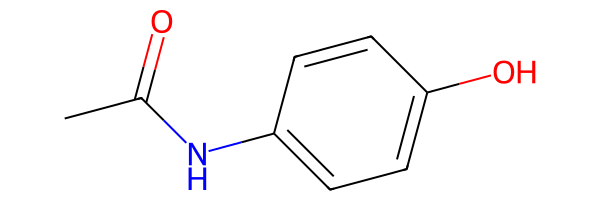

In [20]:
result.draw(width=600)

As expected, `ugropy` fails to obtain the fragmentation of the molecule because 
the `NH` group is not covered by any available fragment, leaving free atoms 
unaccounted for.

First, let's leverage our knowledge from the previous section to retrieve the 
complete data from the UNIFAC model's attributes.

First, the SMARTS DataFrame:

In [21]:
subgroups = unifac.subgroups.copy()

subgroups

,smarts,molecular_weight
group,,
CH3,[CX4H3],15.03500
CH2,[CX4H2],14.02700
CH,[CX4H],13.01900
C,[CX4H0],12.01100
CH2=CH,[CH2]=[CH],27.04600
...,...,...
NCO,[NX2H0]=[CX2H0]=[OX1H0],42.01700
(CH2)2SU,[CH2]S(=O)(=O)[CH2],92.11620
CH2CHSU,[CH2]S(=O)(=O)[CH],91.10840


Since UNIFAC is a `GibbsModel`, we also need to retrieve the fragments
information to instantiate a new model:

In [22]:
subgroups_info = unifac.subgroups_info.copy()

subgroups_info

,subgroup_number,main_group,R,Q
group,,,,
CH3,1,1,0.9011,0.848
CH2,2,1,0.6744,0.540
CH,3,1,0.4469,0.228
C,4,1,0.2195,0.000
CH2=CH,5,2,1.3454,1.176
...,...,...,...,...
NCO,109,51,1.0567,0.732
(CH2)2SU,118,55,2.6869,2.120
CH2CHSU,119,55,2.4595,1.808


Now, lets modify the SMARTS pattern of the `ACNH2` fragment to match both
`ACNH2` and `ACNH` structures and instantiate a new model with the modified
SMARTS pattern:

In [33]:
from ugropy import GibbsModel

# Change directly the SMARTS column for the ACNH2 fragment
# now the aromatic carbon could be bonded to either NH2 or NH.
subgroups.loc["ACNH2", "smarts"] = "[cH0][NH2,NH]"

new_unifac = GibbsModel(
    subgroups=subgroups,
    subgroups_info=subgroups_info,
    calculate_r_q=True
)

Now, lets try to fragment the same molecule with our modified UNIFAC model:

In [34]:
result = new_unifac.get_groups("CC(=O)NC1=CC=C(O)C=C1", "smiles")

print(result.subgroups)

{'ACH': 4, 'ACOH': 1, 'CH3CO': 1, 'ACNH2': 1}


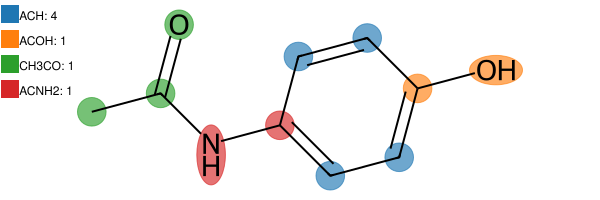

In [35]:
result.draw(width=600)

Now, the structure `ACHNH` is also detected as an `ACNH2` fragment.

### SMARTS tutorial


TODO

### User defined fragmentation models

Users may use the `ugropy` API to define their own fragmentation models. The
basic models API is the `FragmentationModel` class. Instances of this class
have all the methods and attributes necessary to define a fragmentation model.

In [28]:
from ugropy import FragmentationModel

Groups are defined on a `pandas` DataFrame. This is because is convenient
to store the data in a tabular format, and simply read it from a file. You can
check examples on the repository (https://github.com/ipqa-research/ugropy/blob/main/ugropy/groupscsv/unifac/unifac_subgroups.csv)

We can define a simplified UNIFAC fragmentation model as follows:

In [29]:
import pandas as pd

# We define a simple fragmentation model with some common groups.
df = pd.DataFrame(
    {
        "group": ["CH3", "CH2", "CH", "C", "AC", "ACH", "ACCH3", "ACCH2"],
        "smarts": [
            "[CX4H3]",
            "[CX4H2]",
            "[CX4H]",
            "[CX4H0]",
            "[cH0]",
            "[cH]",
            "[cH0][CX4H3]",
            "[cH0][CX4H2]",
        ]
    }
)

# Set the group column as the index
df.set_index("group", inplace=True)


# Define a fragmentation model using the defined groups. UNIFAC-like models
# doesn't allow overlappin groups or atoms that not belong to any group.
mymodel = FragmentationModel(
    subgroups=df,
    allow_overlapping=False,
    allow_free_atoms=False, 
)

With this instance we can detect fragments and solve groups as any other
`ugropy` model. For example:

In [30]:
sol = mymodel.get_groups("toluene")

sol.subgroups

{'ACH': 5, 'ACCH3': 1}

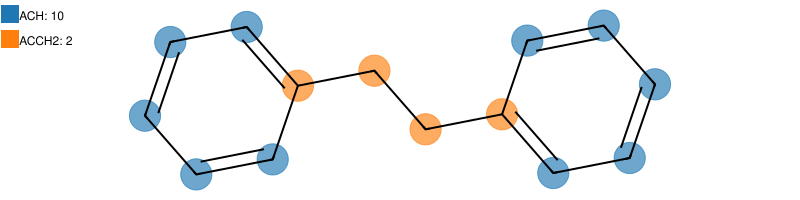

In [31]:
sol = mymodel.get_groups("bibenzyl")

sol.draw(width=800)


The `FragmentationModel.get_groups` method returns a `FragmentationResult`
object. To extend the behavior of the base `FragmentationModel` class, you can
inherit from it and inherit from `FragmentationResult` as well.

An example, could be the `GibbsModel` class and the `GibbsFragmentationResult`
class. The differences between these classes are that receives an extra argument
(the groups' information dataframe). These models work exactly the same but
also calculates the R and Q of the molecule once the fragments are detected.



In [32]:
from ugropy import GibbsFragmentationResult, GibbsModel

You may check these classes source code in the API documentation, it's very
simple to follow and understand how to extend the basic behavior of the base
``FragmentationModel`` class.
